<a href="https://colab.research.google.com/github/Durvankur4/data_science/blob/main/ml_proj_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# My first ML project

# Load DataSet

In [42]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv")

In [43]:
df

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


# Data Preparation

## Separating Data as X and y

In [44]:
X = df.drop("logS",axis=1)
y = df["logS"]

## Splitting the Data

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
from numpy.random.mtrand import random
X_train,X_test,y_train ,y_test = train_test_split(X,y,test_size = 0.2,random_state=100)

In [47]:
X_test

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
822,2.91000,172.268,7.0,0.000000
118,7.27400,360.882,1.0,0.666667
347,1.94040,145.161,0.0,0.909091
1123,1.98640,119.378,0.0,0.000000
924,1.70062,108.140,0.0,0.750000
...,...,...,...,...
1114,1.76210,478.513,4.0,0.000000
427,6.32820,276.338,0.0,1.000000
711,0.04430,218.205,5.0,0.000000
4,2.91890,187.375,1.0,0.000000


# Model Building

## Linear Regression

In [48]:
from sklearn.linear_model import LinearRegression

### **Model training**

In [49]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

### **Applying the model to make predictions**

In [50]:
y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)

### **Evaluate Model Function**

In [51]:
from sklearn.metrics import r2_score,mean_squared_error

In [52]:
lr_train_mse = mean_squared_error(y_train,y_lr_train_pred)
lr_train_r2 = r2_score(y_train,y_lr_train_pred)

In [53]:
lr_test_mse = mean_squared_error(y_test,y_lr_test_pred)
lr_test_r2 = r2_score(y_test,y_lr_test_pred)

In [54]:
lr_evaluation = pd.DataFrame(["Linear Regression",lr_train_mse,lr_train_r2,lr_test_mse,lr_test_r2]).T

In [55]:
lr_evaluation.columns =["Model","Train_mse","Train_r2","Test_mse","Test_r2"]

In [56]:
lr_evaluation

,Model,Train_mse,Train_r2,Test_mse,Test_r2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162


## Random Forest

### Model Training

In [57]:
from sklearn.ensemble import RandomForestRegressor

In [58]:
rf = RandomForestRegressor(max_depth=2,random_state=100)
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=2, random_state=100)

### Applying the model to make predicions

In [59]:
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

### Evaluate Model Function

In [60]:
from sklearn.metrics import mean_squared_error , r2_score

In [61]:
rf_train_mse = mean_squared_error(y_train,y_rf_train_pred)
rf_train_r2 = r2_score(y_train,y_rf_train_pred)

In [62]:
rf_test_mse = mean_squared_error(y_test,y_rf_test_pred)
rf_test_r2 = r2_score(y_test,y_rf_test_pred)

In [63]:
rf_evaluation = pd.DataFrame(["Random Forest",rf_train_mse,rf_train_r2,rf_test_mse,rf_test_r2]).T

In [64]:
rf_evaluation.columns =["Model","Train_mse","Train_r2","Test_mse","Test_r2"]

In [65]:
rf_evaluation

,Model,Train_mse,Train_r2,Test_mse,Test_r2
0,Random Forest,1.028228,0.759669,1.407688,0.709223


## Comparing Both Models

In [66]:
model_comparison = pd.concat([lr_evaluation, rf_evaluation],ignore_index=True)

In [67]:
model_comparison.reset_index(drop=True)

,Model,Train_mse,Train_r2,Test_mse,Test_r2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162
1,Random Forest,1.028228,0.759669,1.407688,0.709223


# Data Visualization

In [68]:
import matplotlib.pyplot as plt
import numpy as np

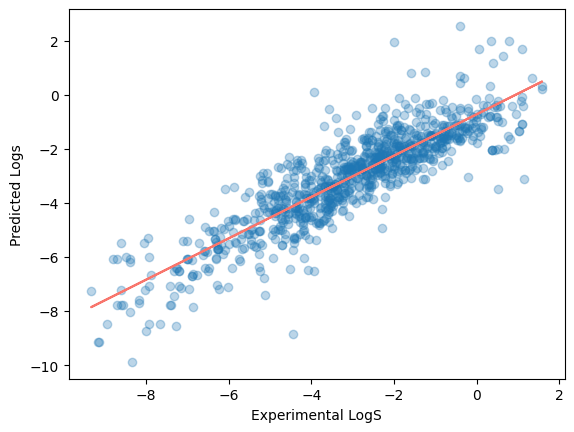

In [69]:
plt.scatter(x = y_train,y = y_lr_train_pred,alpha=0.3)

z = np.polyfit(y_train,y_lr_train_pred,1)
p = np.poly1d(z)

plt.plot(y_train,p(y_train),'#F8766D')
plt.xlabel("Experimental LogS")
plt.ylabel("Predicted Logs")
plt.show()